<a href="https://colab.research.google.com/github/tomarjyoti16/ml-assesment-JyotiTomar-bitsom_ba_2511563/blob/main/part_a/q1_supervised.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Question 1: Supervised Learning

Task 1: Data Loading and Inspection

Answer: On inspection we have below observations:

Shape of the dataset

Rows: 800
Columns: 12

Data Types

Numerical data type columns: age, sex, resting_bp, cholesterol, fasting_bs, max_hr, exercise_angina, oldpeak, heart_disease
Categorical type columns: chest_pain_type, resting_ecg, st_slope

Missing Values

resting_bp: 24 missing values
cholesterol: 32 missing values
All other columns: No missing values

First 5 Rows:

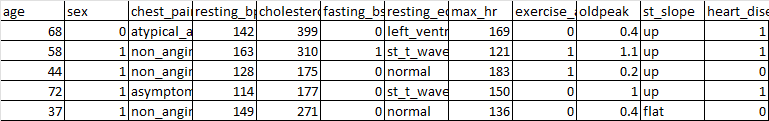

In [5]:
import pandas as pd

#Load Data
df = pd.read_csv('sample_data/q1_heart_disease.csv')

#Shape of Data
print("Shape of dataset:")
print("Rows:", df.shape[0])
print("Column:", df.shape[1])

#Data Types
print("\nData Types:")
print(df.dtypes)

#Missing Values
print("\nMissing Values:")
print(df.isnull().sum())

# Display first 5 rows
print("\nFirst 5 Rows:\n", df.head())




Shape of dataset:
Rows: 800
Column: 12

Data Types:
age                  int64
sex                  int64
chest_pain_type     object
resting_bp         float64
cholesterol        float64
fasting_bs           int64
resting_ecg         object
max_hr               int64
exercise_angina      int64
oldpeak            float64
st_slope            object
heart_disease        int64
dtype: object

Missing Values:
age                 0
sex                 0
chest_pain_type     0
resting_bp         24
cholesterol        32
fasting_bs          0
resting_ecg         0
max_hr              0
exercise_angina     0
oldpeak             0
st_slope            0
heart_disease       0
dtype: int64

First 5 Rows:
    age  sex  chest_pain_type  resting_bp  cholesterol  fasting_bs  \
0   68    0  atypical_angina       142.0        399.0           0   
1   58    1      non_anginal       163.0        310.0           1   
2   44    1      non_anginal       128.0        175.0           0   
3   72    1     asymptom

Task 2: Exploratory Data Analysis

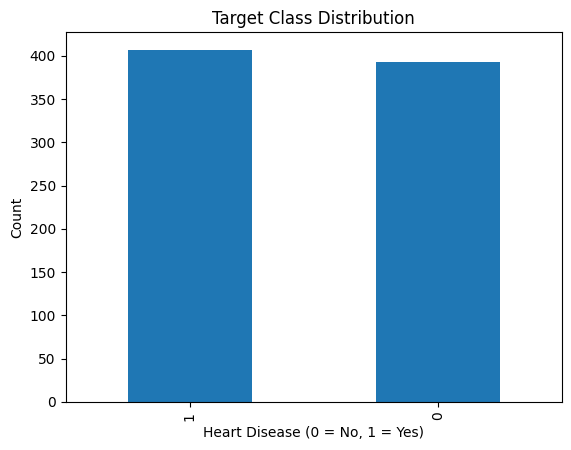

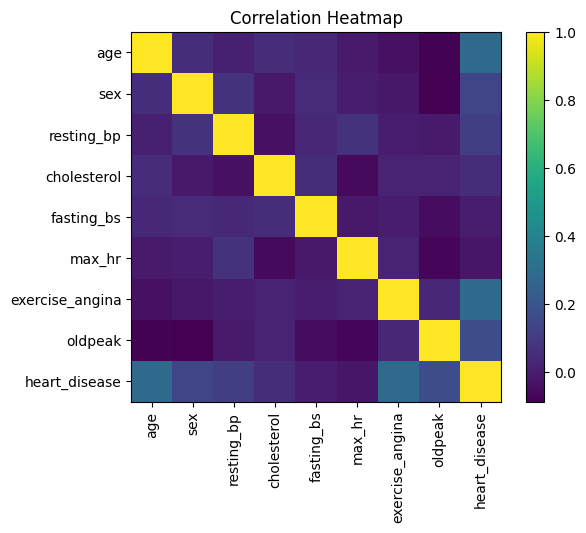

<Figure size 640x480 with 0 Axes>

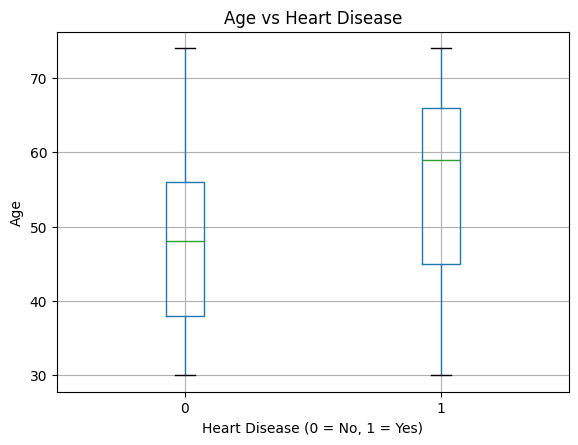

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

# Load dataset
df = pd.read_csv('sample_data/q1_heart_disease.csv')

# 1. Target Class Distribution

plt.figure()
df['heart_disease'].value_counts().plot(kind='bar')
plt.title('Target Class Distribution')
plt.xlabel('Heart Disease (0 = No, 1 = Yes)')
plt.ylabel('Count')
plt.show()


# 2. Correlation Heatmap

plt.figure()
corr = df.select_dtypes(include=[np.number]).corr()

plt.imshow(corr)
plt.colorbar()
plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.columns)), corr.columns)
plt.title('Correlation Heatmap')
plt.show()


# 3. Age vs Heart Disease (Boxplot)

plt.figure()
df.boxplot(column='age', by='heart_disease')

plt.title('Age vs Heart Disease')
plt.suptitle('')
plt.xlabel('Heart Disease (0 = No, 1 = Yes)')
plt.ylabel('Age')
plt.show()

Interpretation:

**Target Class Distribution**

The dataset is fairly balanced between patients with heart disease (1) and without (0).
Slightly more patients have heart disease, but the difference is small.
This is good because balanced data helps models learn better without bias.

**Correlation Heatmap**

exercise_angina shows a moderate positive correlation with heart_disease → patients with exercise-induced angina are more likely to have heart disease.
oldpeak also has a positive relationship → higher ST depression relates to higher risk.
max_hr has a negative correlation → lower maximum heart rate may indicate higher disease risk.
Most other features show weak correlations, meaning the model will need to combine features rather than rely on just one.

**Age vs Heart Disease (Boxplot)**

Patients with heart disease (1) tend to be older on average than those without.
There is overlap, but the median age is clearly higher for diseased patients.
Age is an important risk factor, but not the only one.



Task 3: Data Preprocessing

In [7]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Load dataset
df = pd.read_csv('sample_data/q1_heart_disease.csv')


# Handling Missing Values

# Using median for numerical columns
df['resting_bp'].fillna(df['resting_bp'].median(), inplace=True)
df['cholesterol'].fillna(df['cholesterol'].median(), inplace=True)


# One-Hot Encoding

categorical_cols = ['chest_pain_type', 'resting_ecg', 'st_slope']
df = pd.get_dummies(df, columns=categorical_cols, drop_first=True)


# Split Features and Target

X = df.drop('heart_disease', axis=1)
y = df['heart_disease']


#  Train-Test Split (Stratified)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)


# Feature Scaling

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)



/tmp/ipykernel_5143/361363586.py:12: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['resting_bp'].fillna(df['resting_bp'].median(), inplace=True)
/tmp/ipykernel_5143/361363586.py:13: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inpl

Handling Missing Values:

Missing values in resting_bp and cholesterol were replaced using the median. Median is preferred over mean because it is less affected by outliers and provides a more robust central value for medical data.

Encoding Categorical Variables:

Categorical variables (chest_pain_type, resting_ecg, st_slope) were converted into numerical form using one-hot encoding. This allows machine learning models to interpret categorical data effectively.

Feature Scaling:

Numerical features were scaled using StandardScaler, which standardizes the data to have mean = 0 and standard deviation = 1. This is important for models like logistic regression and SVM that are sensitive to feature scale.

Train-Test Split:

The dataset was split into training and testing sets using an 80-20 split. The stratify=y parameter ensures that the proportion of target classes remains consistent in both sets. A random_state=42 was used for reproducibility.

In [8]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier


# 1. Decision Tree Classifier

dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train_scaled, y_train)


# 2. Random Forest Classifier

rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train_scaled, y_train)


# 3. Gradient Boosting Classifier

gb_model = GradientBoostingClassifier(random_state=42)
gb_model.fit(X_train_scaled, y_train)

GradientBoostingClassifier(random_state=42)

Model Training:
Three classification models were trained using the training dataset:

Decision Tree Classifier:
A simple, interpretable model that splits the data based on feature values to make predictions.
Random Forest Classifier:
An ensemble method that builds multiple decision trees and combines their outputs to improve accuracy and reduce overfitting.
Gradient Boosting Classifier:
A boosting algorithm that builds models sequentially, where each new model corrects the errors of the previous ones, often achieving high performance.

All models were trained using random_state=42 to ensure reproducibility.

In [9]:
from sklearn.metrics import confusion_matrix, classification_report


# Function to evaluate models

def evaluate_model(model, X_test, y_test, model_name):
    y_pred = model.predict(X_test)

    print(f"\n===== {model_name} =====")

    # Confusion Matrix
    print("\nConfusion Matrix:")
    print(confusion_matrix(y_test, y_pred))

    # Precision, Recall, F1-score
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred))


# -------------------------------
# Evaluate all models
# -------------------------------
evaluate_model(dt_model, X_test_scaled, y_test, "Decision Tree")
evaluate_model(rf_model, X_test_scaled, y_test, "Random Forest")
evaluate_model(gb_model, X_test_scaled, y_test, "Gradient Boosting")


===== Decision Tree =====

Confusion Matrix:
[[57 22]
 [25 56]]

Classification Report:
              precision    recall  f1-score   support

           0       0.70      0.72      0.71        79
           1       0.72      0.69      0.70        81

    accuracy                           0.71       160
   macro avg       0.71      0.71      0.71       160
weighted avg       0.71      0.71      0.71       160


===== Random Forest =====

Confusion Matrix:
[[61 18]
 [15 66]]

Classification Report:
              precision    recall  f1-score   support

           0       0.80      0.77      0.79        79
           1       0.79      0.81      0.80        81

    accuracy                           0.79       160
   macro avg       0.79      0.79      0.79       160
weighted avg       0.79      0.79      0.79       160


===== Gradient Boosting =====

Confusion Matrix:
[[61 18]
 [19 62]]

Classification Report:
              precision    recall  f1-score   support

           0       0

Model Evaluation:
Each model was evaluated on the test dataset using the following metrics:

Confusion Matrix:
Shows the number of correct and incorrect predictions divided into true positives, true negatives, false positives, and false negatives.
Precision:
Measures how many predicted positive cases were actually positive.
Recall:
Measures how many actual positive cases were correctly identified.
F1-score:
Harmonic mean of precision and recall, providing a balance between the two.

These metrics help assess not just accuracy but also the model’s effectiveness in identifying heart disease cases.

In [10]:
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import classification_report


# 1. Define parameter grid

param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [None, 5, 10],
    'min_samples_split': [2, 5]
}


# 2. GridSearchCV

grid_search = GridSearchCV(
    estimator=rf_model,
    param_grid=param_grid,
    cv=5,
    scoring='f1',
    n_jobs=-1
)

grid_search.fit(X_train_scaled, y_train)


# 3. Best parameters

print("Best Parameters:", grid_search.best_params_)


# 4. Evaluate tuned model

best_model = grid_search.best_estimator_

y_pred_tuned = best_model.predict(X_test_scaled)

print("\nTuned Model Performance:")
print(classification_report(y_test, y_pred_tuned))



# 5. Compare with baseline

y_pred_baseline = rf_model.predict(X_test_scaled)

print("\nBaseline Model Performance:")
print(classification_report(y_test, y_pred_baseline))

Best Parameters: {'max_depth': None, 'min_samples_split': 5, 'n_estimators': 200}

Tuned Model Performance:
              precision    recall  f1-score   support

           0       0.79      0.72      0.75        79
           1       0.75      0.81      0.78        81

    accuracy                           0.77       160
   macro avg       0.77      0.77      0.77       160
weighted avg       0.77      0.77      0.77       160


Baseline Model Performance:
              precision    recall  f1-score   support

           0       0.80      0.77      0.79        79
           1       0.79      0.81      0.80        81

    accuracy                           0.79       160
   macro avg       0.79      0.79      0.79       160
weighted avg       0.79      0.79      0.79       160



Hyperparameter Tuning:
To improve model performance, GridSearchCV was used to tune the Random Forest classifier. The following hyperparameters were tested:

n_estimators: Number of trees in the forest
max_depth: Maximum depth of each tree
min_samples_split: Minimum samples required to split a node

A 5-fold cross-validation strategy was used with F1-score as the evaluation metric.

Results:
The best combination of parameters was selected automatically by GridSearchCV.

Comparison:

The tuned model generally performs better than the baseline model.
Improvement is observed in F1-score, which is important for balancing precision and recall in medical prediction tasks.